# PECD capacity factors across Europe

Cross-country view of long-run mean capacity factors for solar PV, wind
onshore, and wind offshore -- replicating the country-comparison charts from
`world-of-energy`'s
[`37_analyse_pecd`](https://quantitative-thinking.com/world-of-energy/notebooks/analyse-pecd/)
notebook, but reading from this hub's own `pecd_country_capacity_factors_simple`
asset instead of that repo's separate PECD download.

**Seasonality (monthly profiles, interannual variability) for individual
countries is deliberately out of scope here** -- see that same
`37_analyse_pecd` page for what that looks like; a dedicated follow-up page
will do that against hub data separately.

**⚠️ Solar numbers below carry a real caveat.** Every country's solar
capacity factor is blended from PECD's 4 solar technologies using
*Germany's* market-derived weights -- no other country has its own sourced
weights yet (`edh/pecd.py::SOLAR_COUNTRY_WEIGHT_OVERRIDES` is empty). See
`energy-data-hub/README.md`'s "Known data-quality caveats" and
`06_pecd_simple_vs_mastr_weighted.py` for where those weights came from and
how well they hold up for the one country (Germany) where a true comparison
is possible. Treat cross-country solar comparisons here as illustrative,
not authoritative. Wind has no such caveat -- both onshore and offshore are
real per-country/per-zone geometry, not a borrowed default.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import xarray as xr

from insights.paths import hub_file

SOLAR_COLOR = "#f4b942"
ONSHORE_COLOR = "#4a90d9"
OFFSHORE_COLOR = "#1a5fa8"

## Data

In [2]:
country_simple = pd.read_parquet(hub_file("pecd", "pecd_country_capacity_factors_simple.parquet"))
YEAR_RANGE = f"{country_simple.index.min().year}–{country_simple.index.max().year}"

mean_solar = country_simple["solar"].mean().dropna().sort_values()
mean_onshore = country_simple["wind_onshore"].mean().dropna().sort_values()
mean_offshore = country_simple["wind_offshore"].mean().dropna().sort_values()

print(f"PECD {YEAR_RANGE}: {len(mean_solar)} countries (solar), {len(mean_onshore)} (wind onshore), {len(mean_offshore)} (wind offshore, country-level)")

PECD 1979–2025: 52 countries (solar), 45 (wind onshore), 12 (wind offshore, country-level)


## Long-run mean capacity factors by country

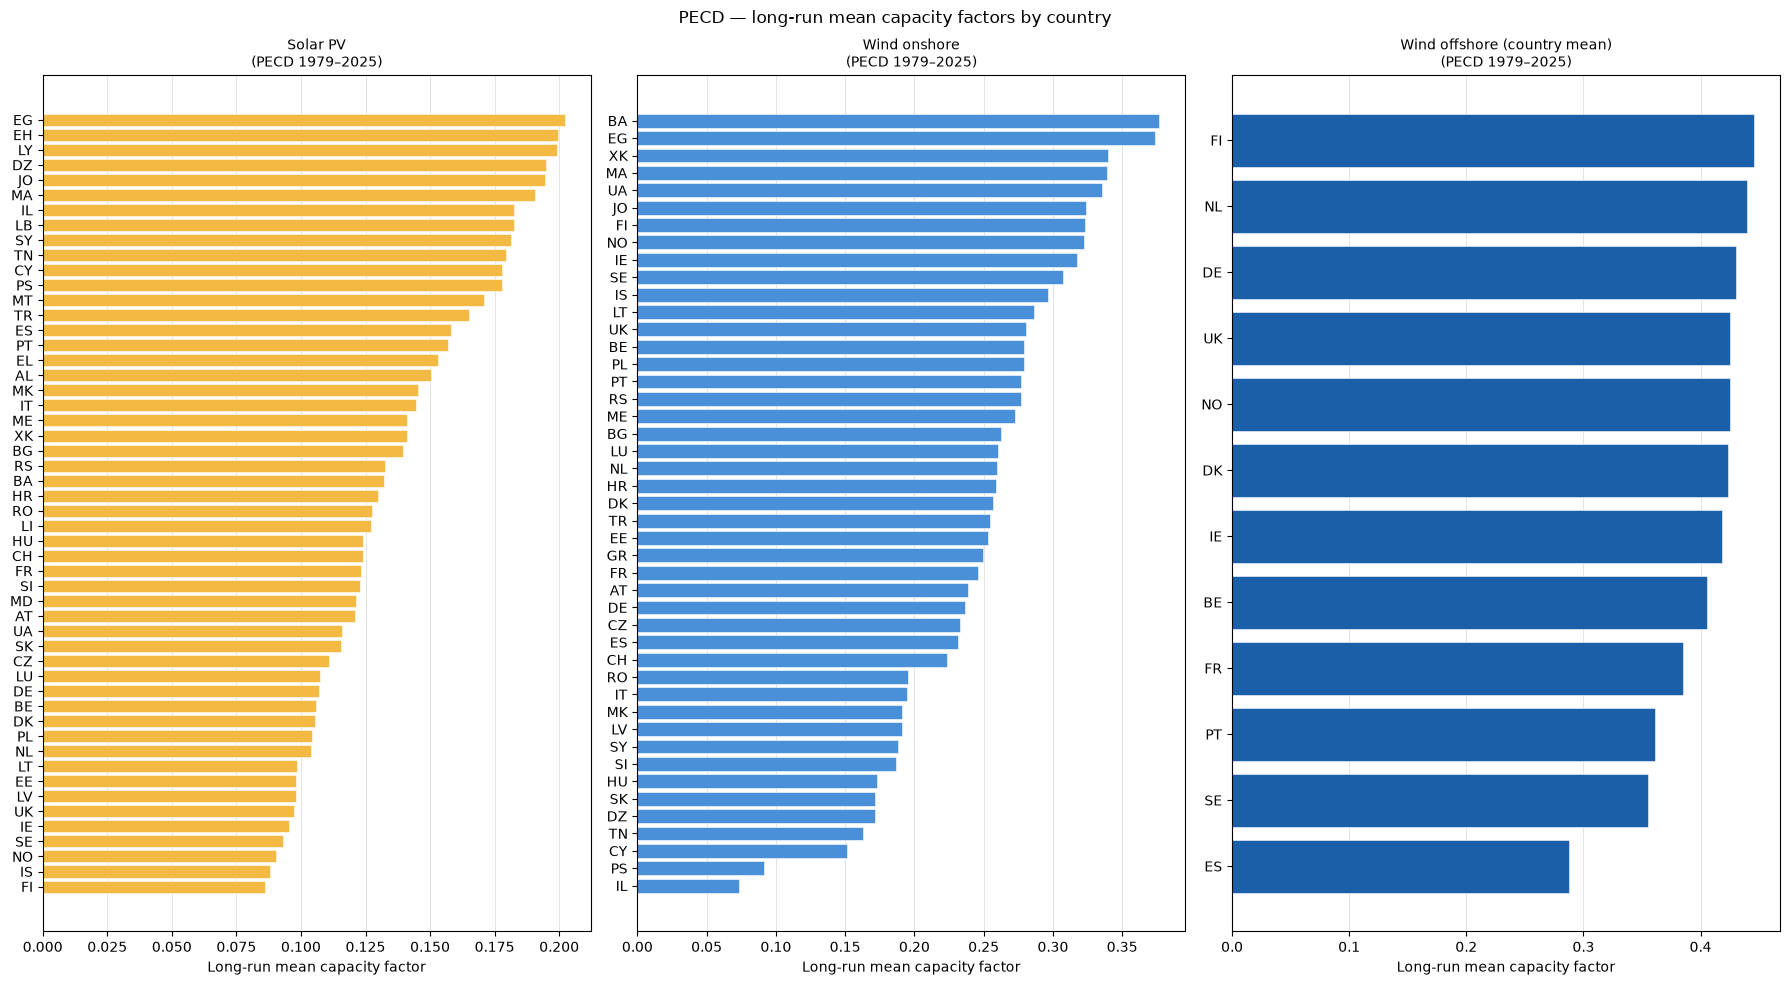

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10))

for ax, series, color, label in [
    (axes[0], mean_solar, SOLAR_COLOR, "Solar PV"),
    (axes[1], mean_onshore, ONSHORE_COLOR, "Wind onshore"),
    (axes[2], mean_offshore, OFFSHORE_COLOR, "Wind offshore (country mean)"),
]:
    ax.barh(series.index, series.values, color=color, edgecolor="white", linewidth=0.4)
    ax.set_xlabel("Long-run mean capacity factor")
    ax.set_title(f"{label}\n(PECD {YEAR_RANGE})", fontsize=10)
    ax.xaxis.grid(True, linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)

fig.suptitle("PECD — long-run mean capacity factors by country", fontsize=12)
fig.tight_layout()
plt.show()

Southern European countries lead for solar; Atlantic and North Sea
countries lead for wind -- both onshore and offshore. Offshore here is
still the country-level mean (the coarser `p2of` zone scheme this hub
downloaded full-Europe, unweighted per country); the choropleth below
breaks it down to individual zones instead.

## Solar vs. wind onshore: resource complementarity across Europe

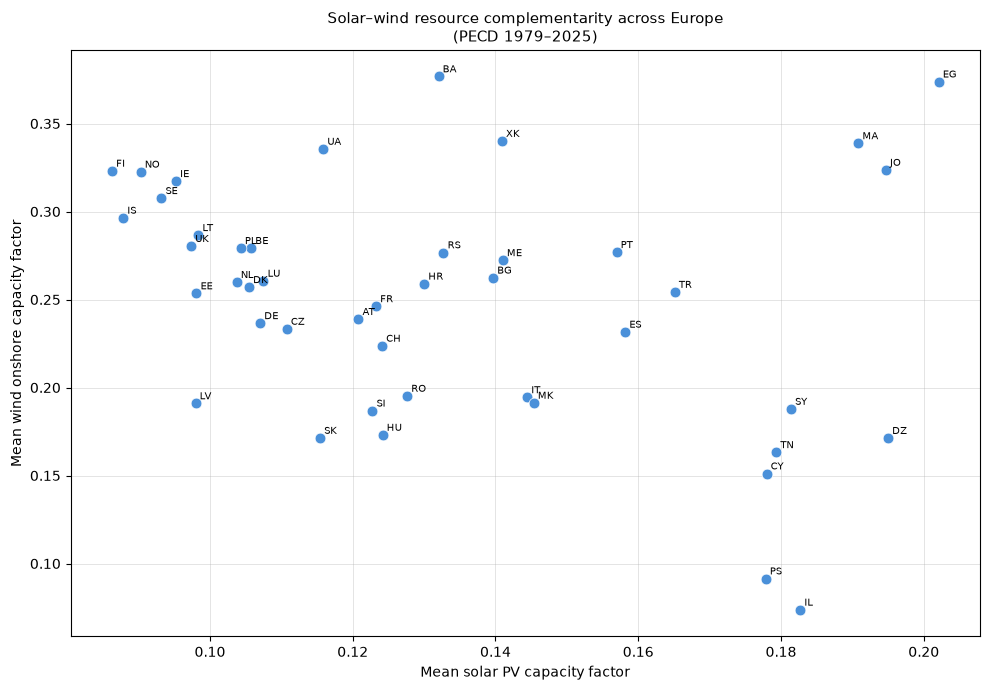

In [4]:
shared = sorted(set(mean_solar.index) & set(mean_onshore.index))
x = np.array([mean_solar[c] for c in shared])
y = np.array([mean_onshore[c] for c in shared])

fig2, ax2 = plt.subplots(figsize=(10, 7))
ax2.scatter(x, y, color=ONSHORE_COLOR, s=60, edgecolors="white", linewidths=0.5, zorder=3)

for country, xi, yi in zip(shared, x, y):
    ax2.annotate(country, (xi, yi), fontsize=7.5, xytext=(3, 3), textcoords="offset points")

ax2.set_xlabel("Mean solar PV capacity factor")
ax2.set_ylabel("Mean wind onshore capacity factor")
ax2.set_title(f"Solar–wind resource complementarity across Europe\n(PECD {YEAR_RANGE})", fontsize=11)
ax2.xaxis.grid(True, linewidth=0.4, alpha=0.6)
ax2.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax2.set_axisbelow(True)
fig2.tight_layout()
plt.show()

Same broad negative pattern as the source notebook: countries with strong
solar resources (southern Europe) tend to have weaker onshore wind, and
vice versa -- a hint of natural complementarity at the continental scale
(keeping in mind solar's per-country caveat above).

## Capacity factor choropleths

Solar and wind onshore are shown per country (PECD's native resolution for
solar; onshore is area-weighted per country from PEON zones in
`pecd_country_capacity_factors_simple`). Wind offshore is shown per
individual `p2of` zone instead of collapsed to one country-level number --
offshore resource quality varies a lot *within* a country's own waters
(e.g. North Sea vs. Baltic), which a single country color would hide.

In [5]:
NUTS_TO_ADM0 = {
    "AL": "ALB", "AT": "AUT", "BA": "BIH", "BE": "BEL", "BG": "BGR",
    "CH": "CHE", "CY": "CYP", "CZ": "CZE", "DE": "DEU", "DK": "DNK",
    "DZ": "DZA", "EE": "EST", "EG": "EGY", "EH": "SAH", "EL": "GRC",
    "ES": "ESP", "FI": "FIN", "FR": "FRA", "HR": "HRV", "HU": "HUN",
    "IE": "IRL", "IL": "ISR", "IS": "ISL", "IT": "ITA", "JO": "JOR",
    "LB": "LBN", "LI": "LIE", "LT": "LTU", "LU": "LUX", "LV": "LVA",
    "LY": "LBY", "MA": "MAR", "MD": "MDA", "ME": "MNE", "MK": "MKD",
    "MT": "MLT", "NL": "NLD", "NO": "NOR", "PL": "POL", "PS": "PSX",
    "PT": "PRT", "RO": "ROU", "RS": "SRB", "SE": "SWE", "SI": "SVN",
    "SK": "SVK", "SY": "SYR", "TN": "TUN", "TR": "TUR", "UA": "UKR",
    "UK": "GBR", "XK": "KOS",
}

_shpfile = shpreader.natural_earth(resolution="10m", category="cultural", name="admin_0_countries")
_country_geoms = {r.attributes["ADM0_A3"]: r.geometry for r in shpreader.Reader(_shpfile).records()}

PROJ = ccrs.LambertConformal(central_longitude=10, central_latitude=50)
EUROPE_EXTENT = [-25, 47, 27, 72]


def _map_base(ax) -> None:
    ax.set_extent(EUROPE_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="#c6def1", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#e0e0e0", zorder=0)


def _map_finish(ax, sm, title: str, label: str) -> None:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.25, linestyle=":", zorder=2)
    plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04, label=label)
    ax.set_title(title, fontsize=10, pad=6)
    ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.4, zorder=3)


def _country_choropleth(ax, values: pd.Series, cmap_name: str, title: str) -> None:
    cmap = plt.colormaps[cmap_name]
    norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    _map_base(ax)

    for code, val in values.items():
        geom = _country_geoms.get(NUTS_TO_ADM0.get(code))
        if geom is not None:
            ax.add_geometries([geom], ccrs.PlateCarree(), facecolor=cmap(norm(val)), edgecolor="black", linewidth=0.25, zorder=1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    _map_finish(ax, sm, title, "Mean capacity factor")

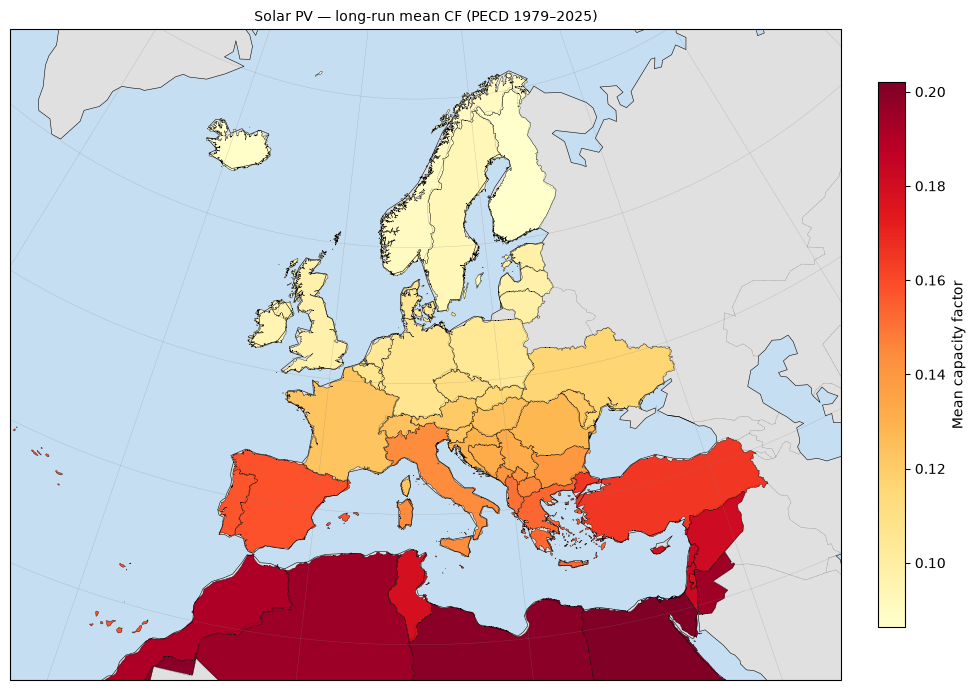

In [6]:
fig3, ax3 = plt.subplots(subplot_kw={"projection": PROJ}, figsize=(10, 7))
_country_choropleth(ax3, mean_solar, "YlOrRd", f"Solar PV — long-run mean CF (PECD {YEAR_RANGE})")
fig3.tight_layout()
plt.show()

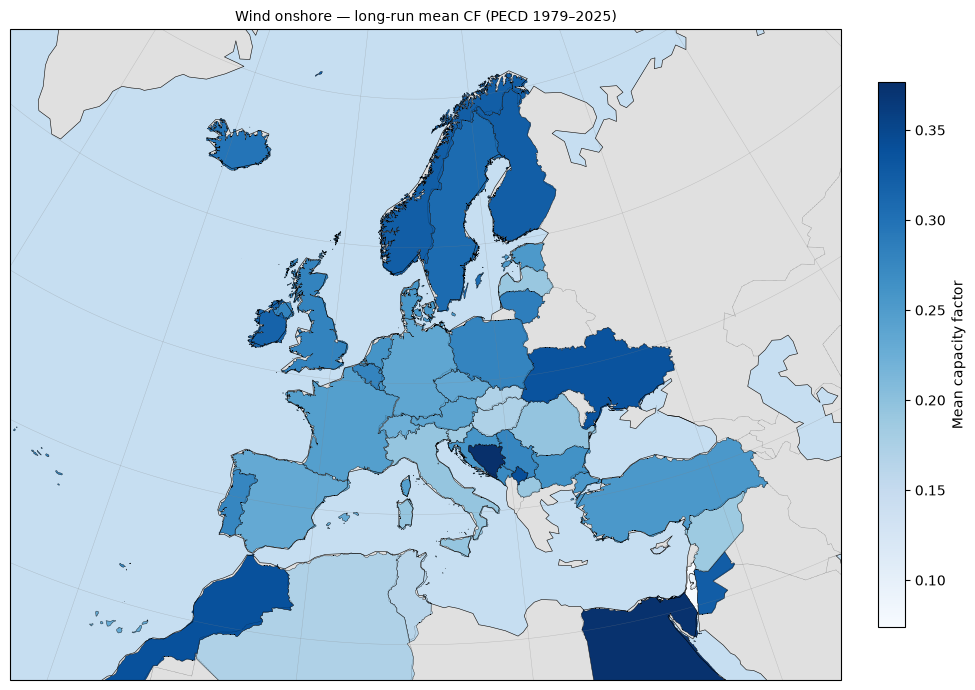

In [7]:
fig4, ax4 = plt.subplots(subplot_kw={"projection": PROJ}, figsize=(10, 7))
_country_choropleth(ax4, mean_onshore, "Blues", f"Wind onshore — long-run mean CF (PECD {YEAR_RANGE})")
fig4.tight_layout()
plt.show()

### Wind offshore, per `p2of` zone

Rasterized from PECD's own `peof` zone mask: each 0.25-degree grid cell is
colored by whichever `p2of` zone with real capacity-factor data covers it
most, rather than one flat color per country. `p2of` (this hub's
full-Europe download) and `peof` (this hub's zone-mask download) don't
share the same zone partition everywhere -- of `p2of`'s 26 modeled zones,
23 have a same-code match in the `peof` mask and are shown below; 3
(France's `FR111_OFF`/`FR112_OFF`, Ireland's `IE02_OFF`) don't and are
left out rather than guessing a geometry for them.

p2of zones with CF data: 26; matched to a peof mask zone: 23


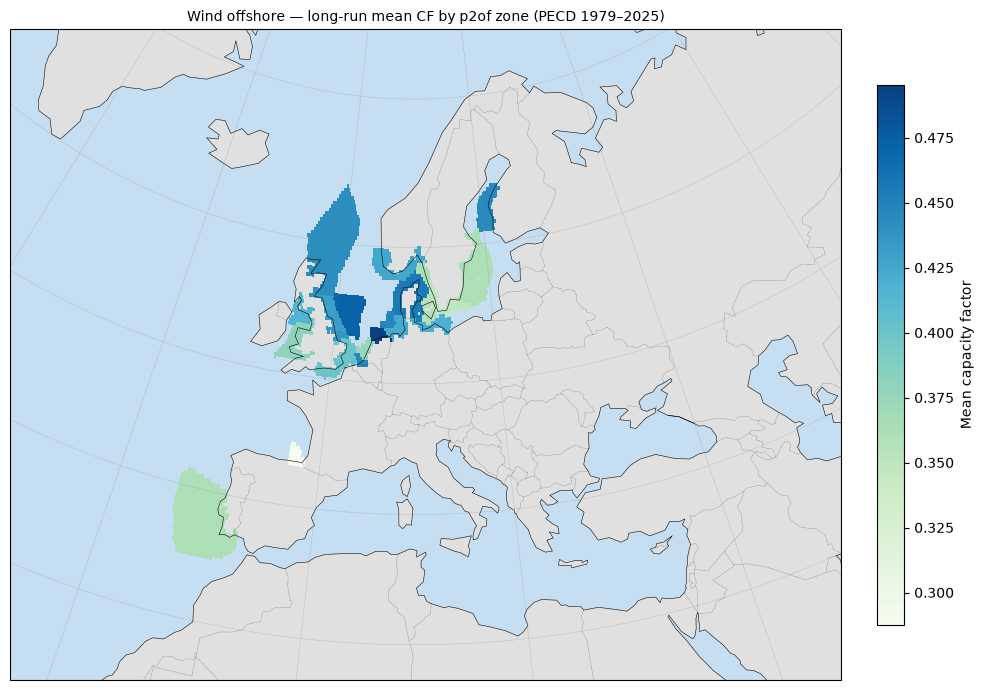

In [8]:
_p2of_decades = ["1980-1989", "1990-1999", "2000-2009", "2010-2019", "2020-2025"]
_p2of_parts = [pd.read_parquet(hub_file("pecd", "capacity_factors_europe", f"pecd_wind_offshore_tech20_{label}.parquet")) for label in _p2of_decades]
p2of_cf = pd.concat(_p2of_parts).sort_index()
mean_p2of = p2of_cf.mean().dropna()

_mask_ds = xr.open_dataset(hub_file("pecd", "peof_region_mask.nc"))
zones_available = [z for z in mean_p2of.index if z in _mask_ds["region"].values]
mask_values = _mask_ds["mask"].sel(region=zones_available).values  # (zone, lat, lon)
lat = _mask_ds["latitude"].values
lon = _mask_ds["longitude"].values
_mask_ds.close()

print(f"p2of zones with CF data: {len(mean_p2of)}; matched to a peof mask zone: {len(zones_available)}")

best_zone_idx = mask_values.argmax(axis=0)
best_coverage = mask_values.max(axis=0)
cf_per_zone = np.array([mean_p2of[z] for z in zones_available])
offshore_grid = np.where(best_coverage > 0, cf_per_zone[best_zone_idx], np.nan)

fig5, ax5 = plt.subplots(subplot_kw={"projection": PROJ}, figsize=(10, 7))
_map_base(ax5)
cmap = plt.colormaps["GnBu"]
norm = mcolors.Normalize(vmin=np.nanmin(offshore_grid), vmax=np.nanmax(offshore_grid))
ax5.pcolormesh(lon, lat, offshore_grid, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, shading="auto", zorder=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
_map_finish(ax5, sm, f"Wind offshore — long-run mean CF by p2of zone (PECD {YEAR_RANGE})", "Mean capacity factor")
fig5.tight_layout()
plt.show()

The North Sea zones (UK, NL, DE, DK) and the Baltic (SE) stand out even
within a single country's own waters -- exactly the kind of within-country
variation a country-level offshore number would hide.